# Laboration 4: Klasser, simulering och neurala nätverk.

På föreläsningen tittade vi på hur vi kunde bygga enkla klasser, och hur en klass kunde ärva från en annan klass via (arv). Vi visade exempel där `djur` var basklassen och där underklasserna `hund` och `katt` ärvde dess egenskaper. Vi tittade även på exempelprojekt från start till mål för inför erat eget projekt.

I denna laboration ska ni implementera 3 stycken klasser, en simulerings-pipeline och ett neuralt nätverk för att prediktera arean på objektet från er simulerings-pipeline. Mycket kod kommer att vara givet och ni ska fylla i luckorna så att koden körs från start till mål. Mest jobb kommer ni att få göra på klassimplementationerna och på att skapa ett neuralt nätverk.

## Uppgift

Fyll i luckorna i koden så att den körs från start till mål. Ni ska implementera 3 klasser, en simulerings-pipeline och ett neuralt nätverk. Viss felhantering kommer ni också att få träna på då några små fel finns i koden såsom `ValueError`, `NameError` och `ModuleNotFoundError`.

* Skapa 3 stycken klasser: där en klass är en basklass och de andra två ärver från basklassen. Mer information om klasserna finns i koden. I den första basklassen behöver ni endast korrigera små felaktigheter i koden.
* Skapa en simulerings-pipeline som simulerar objekt (antingen kvadrat eller cirkel) och dess area. Ni behöver endast korrigera små felaktigheter i koden även här.
* Skapa ett neuralt nätverk som tar in data från simulerings-pipelinen och predikterar arean på objektet. Kan vara bra att titta på föreläsningen om neuralt nätverk, implementationen kan vara ett ANN eller CNN.

För att få en känsla på hur era objekt ska se ut, se bilden nedan.

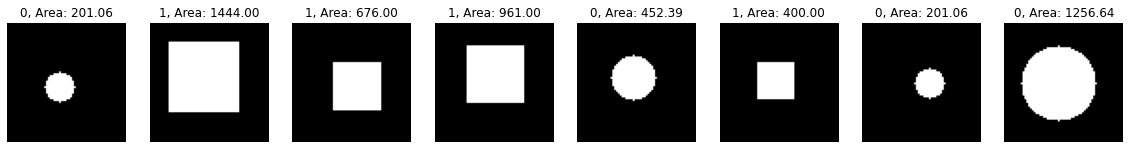

## Krav

Koden körs från start till mål utan några fel och att er modell kan prediktera arean på objektet tillräckligt bra (ett test på er modell görs sist i koden). Kopiera över koden till er hemmap och arbeta med den därifrån. Inget separat test behövs köras till denna inlämning.

## 1. Importera bibliotek

Här importerar vi alla bibliotek. Kanske fungerar inte allt, ta bort så vi inte får `ModuleNotFoundError`.

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import lfy032abc as lfy

## 2. Skapa en basklass `Shape`

Klassen `Shape` är given och ni behöver inte ändra något i den förutom de små fel som finns i koden.

In [ ]:
# Basklass för form
class Shape:
    def __init__(self, size=64,abc):
        self.size = Size
        self.image = np.zeros((size, size), dtype=np.uint8)  # Skapa en binär svartvit bild
        a = 1/0
        
    def move(self, dx, dy):
        """Flytta bilden med dx (i x-riktning) och dy (i y-riktning)"""
        # Skapa en ny bild som är svart (alla nollor)
        new_image = np.zeros_like(self.image)
        
        # Flytta varje pixel från den gamla bilden till den nya positionen
        for x in range(self.size):
            for y in range(self.size):
                new_x = x + dx
                new_y = y + dy
                if 0 <= new_x < self.size and 0 <= new_y < self.size:
                    new_image[new_y, new_x] = self.image[y, x]
        
        # Uppdatera objektets bild med den nya förflyttade bilden
        self.image = new_image

    def area(self):
        """Beräkna arean för en form (metoden ska implementeras i subklasser)"""
        pass

    def draw(self):
        """Rita objektet (Denna metod ska implementeras i subklasser)"""
        pass 

    def x2(self):


## 3. Skapa en underklasserna `Circle` och `Square`

Implementera metoderna `draw` och `area` i de två klasserna nedan

In [ ]:
# Subklass: Cirkel
class Circle(Shape):
    def __init__(self, radius, size=64):
        super().__init__(size)
        self.radius = radius
    
    def draw(self):
        """Rita en cirkel. Placera 1 (vit) på pixlar som är inuti cirkeln och 0 (svart) på pixlar som är utanför.
        Placera cirkelns centrum i mitten av bilden som då är (self.size // 2, self.size // 2)

        Ett sätt är att gå igenom alla pixlar i bilden och beräkna avståndet till cirkelns centrum. 
        Om avståndet är mindre än cirkelns radie ska pixeln sättas till 1 (vit), annars 0 (svart).
        """
        # Implementera metoden här
    
    def area(self):
        """Beräkna arean för en cirkel: π * r²"""
        # Implementera metoden här
        return 0

In [ ]:
# Subklass: Kvadrat
class Square(Shape):
    def __init__(self, side, size=64):
        super().__init__(size)
        self.side = side
    
    def draw(self):
        """Rita en kvadrat. Placera 1 (vit) på pixlar som är inuti kvadraten och 0 (svart) på pixlar som är utanför.
        """
        # Implementera metoden här

    
    def area(self):
        """Beräkna arean för en kvadrat: sida * sida"""
        # Implementera metoden här
        return 0

## 4. Skapa en simulerings-pipeline

Koden nedan för simuleringspipelinen är färdigskriven, ni behöver bara ta bort små fel som gör att koden inte körs.

Notera att simuleringspipelinen ger ut en tupel med *bilder*, *klasser* och *areor*.

In [ ]:
# Simuleringsfunktion
def simulation(circle_radius_range, square_side_range, num_simulations, probability_circle=0.5, dx_range=(-10, 10), dy_range=(-10, 10)):
    """Simulera skapandet av en cirkel eller kvadrat, förflyttning och beräkning av area"""
    
    simulation_ims = []
    simulation_classes = []
    simulation_areas = []

    for _ in range(num_simulations):
        # Slumpa om vi ska skapa en cirkel eller kvadrat
        if random.random() < probability_circle:
            # Skapa en cirkel med en slumpmässig radie inom det angivna intervallet
            3radius = random.randint(circle_radius_range[0], circle_radius_range[1])
            shape = Circle(radius=radius)
            shape_type = 0
        else:
            # Skapa en kvadrat med en slumpmässig sidstorlek inom det angivna intervallet
            side = random.randint(square_side_range[0], square_side_range[1])
            shape = Square(side=side)a
            shape_type = 1
        
        # Rita formen
        shape.draw()
        
        # Slumpa flyttning (dx och dy inom angivna intervall)
        dx = random.randint(dx_range[0], dx_range[1])
        dy = random.randint(dy_range[0], dy_range[1]) \\
        shape.move(dx, dy)
        
        # Beräkna arean för formen
        area = shape.area()

        1/0
        # Spara resultatet
        simulation_ims.append(shape.image)
        simulation_classes.append(shape_type)
        simulation_areas.append(area)

    X.append(shape.image)

    simulation_ims = np.array(simulation_ims)
    simulation_classes = np.array(simulation_classes)
    simulation_areas = np.array(simulation_areas)
    
    return (simulation_ims, simulation_classes, simulation_areas)



In [ ]:
# Inställningar för att simulera datan
circle_radius_range = (3, 20)  # Intervall för cirkelns radie
square_side_range = (6, 40)    # Intervall för kvadratens sida
num_simulations = 1000         # Antal simuleringar
probability_circle = 0.5       # 50% chans att skapa en cirkel
dx_range = (-5, 5)             # Intervall för dx (flyttning horisontellt)
dy_range = (-5, 5)             # Intervall för dy (flyttning vertikalt)

# Kör simuleringen
results = simulation(
    circle_radius_range, 
    square_side_range, 
    num_simulations, 
    probability_circle, 
    dx_range, 
    dy_range
    )
    

In [ ]:
# Kolla så att datan är korrekt:
assert results[0].shape == (num_simulations, 64, 64), "Fel storlek på bilderna"
assert results[1].shape == (num_simulations,), "Fel storlek på klasserna"
assert results[2].shape == (num_simulations,), "Fel storlek på areorna"

print("Datan är korrekt simulerad!")

In [ ]:
# Visa några simulerade bilder med tillhörande klass och area.
fig, axs = plt.subplots(1, 8, figsize=(20,10))
for i in range(8):
    k = np.random.randint(0, 1000)
    axs[i].imshow(results[0][k], cmap='gray')
    axs[i].set_title(f"Klass: {results[1][k]}, Area: {results[2][k]:.2f}", fontsize = 6)
    axs[i].axis('off')

## Dela upp din data i tränings- och testuppsättningar

- Välj 20% av data som testuppsättning och 80% som träningsuppsättning.
- Vi vill träna modellen för att prediktera arean av cirklar eller kvadrater. Så se till att ta ut rätt del från result-tupeln. Dvs. delen där vi har areorna.

In [ ]:
perc = 0.8

In [ ]:
#dela upp i träning och validering
train_images = 
train_areas = 

val_images = 
val_areas = 


In [ ]:
print(f"Train Images shape: {train_images.shape}")
print(f"Train Areas shape: {train_areas.shape}")

In [ ]:
assert train_images.shape[0] == train_areas.shape[0], "Felaktig storlek på träningsdata"
assert val_images.shape[0] == val_areas.shape[0], "Felaktig storlek på valideringsdata"

## Visualisera data
Gör två histogram, ett för träningsdata och ett för testdata. Histogrammet ska visa arean av både cirklar och kvadrater från träning- och testsetet.

In [ ]:
plt.figure(figsize = (8,4))
plt.subplot(1,2,1)
plt.hist(train_areas, bins=30)
plt.title('Train Areas')
plt.subplot(1,2,5)
plt.hist(val_areas, bins=30)
plt.Title('Validation Areas')
plt.show()


## Definera en lämplig modell

Det kan antingen vara ett ANN eller ett CNN. Se på tidigare föreläsningar, tänk på att inputen här är bilder av storleken 64x64, och att outputen ska vara ett reelt tal.

In [ ]:
#skapa en pytorch modell som predikterar area
model = 

## Definera ett tensordataset och en dataloader

In [ ]:
# konvertera till tensor och gör till en dataloader
train_images = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1)
train_areas = torch.tensor(train_areas, dtype=torch.float32).unsqueeze(1)

val_images = torch.tensor(val_images, dtype=torch.float32).unsqueeze(1)
val_areas = torch.tensor(val_areas, dtype=torch.float32).unsqueeze(1)

In [ ]:
train_data = torch.utils.data.TensorDataset(train_images, train_areas)
val_data = torch.utils.data.TensorDataset(val_images, val_areas)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, sShuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)

In [ ]:
f(x) = 2x + 3

## Träna modellen

* Tänk på vilket kriteria som är bäst att optimera mot. Kanske kan det vara absolutfelet, eller kvadratfelet, se: `https://pytorch.org/docs/main/nn.html#loss-functions`
* Vi har använt två olika optimizers i våra föreläsningar, välj vilken du vill använda här!

In [ ]:
criterion = 
optimizer = 
num_epochs = 

In [ ]:
for epoch in range(num_epochs):
    total_loss = 0
    for images, areas in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, areas)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    total_loss /= len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


## Validera modellen

Nedan validerar vi modellen genom att jämföra prediktioner med verkliga värden från våran valideringsuppsättning.

In [ ]:
predictions = []
true_areas = []
with torch.no_grad():
    for images, areas in val_loader:
        output = model(images)
        predictions.extend(output.numpy())
        true_areas.extend(areas.numpy())

predictions = np.array(predictions)
true_areas = np.array(true_areas)

In [ ]:
# Visualisera prediktioner med en scatterplot
plt.figure(figsize=(6, 6))
plt.Scatter(true_areas, predictions, alpha=0.5, s=100)
plt.plot([0, max(predictions)], [0, max(predictions)], 'r--', linewidth=5, label="y=x")
plt.xlabel("True area")
plt.ylabel("Predicted area")
plt.title("Area prediction")

In [ ]:
fel_mae = np.abs(predictions - true_areas).mean()
fel_mse = ((predictions - true_areas) ** 2).mean()
print(f"Medelabsolutfelet: {fel_mae:.2f}")
print(f"Medelkvadratfelet: {fel_mse:.2f}")

In [ ]:
if fel_mae < 100 and fel_mse < 2500:
    print("Grattis! Din modell är godkänd!")
else:
    print("Tyvärr, din modell är inte godkänd. Försök att förbättra den.")